In [1]:
# Cell 1 — Imports & load data
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

DATA_PATH = "../data/bus_2025-07-28_2025-08-03.parquet"
OUTPUT_DIR = "quality_report"

df = (
    pl.read_parquet(DATA_PATH)
    .with_columns(
        pl.col("tst_iso").str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z')
    )
)
print(f"总行数: {len(df):,}")

总行数: 5,728,505


distanz 统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.728505e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 210.020259 │
│ std        ┆ 453.957524 │
│ min        ┆ 0.0        │
│ 25%        ┆ 3.0        │
│ 50%        ┆ 94.0       │
│ 75%        ┆ 321.0      │
│ max        ┆ 21430.0    │
└────────────┴────────────┘

负值数量 : 0
零值数量 : 1,135,082
最大值   : 21,430 m


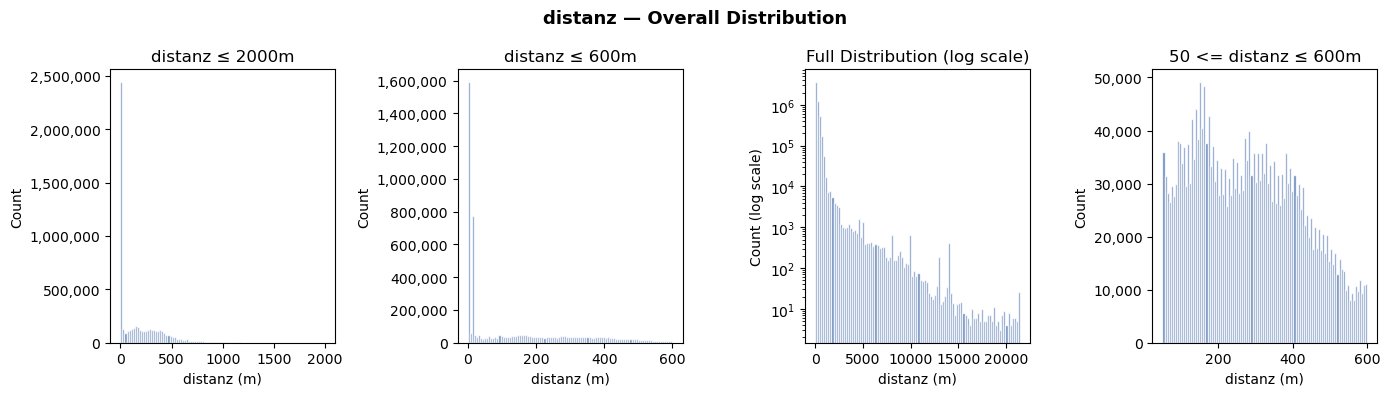

In [2]:
# Cell 2 — distanz 基本分布
distanz = df["distanz"].drop_nulls().to_numpy()

print("distanz 统计：")
print(df["distanz"].describe())
print(f"\n负值数量 : {(df['distanz'] < 0).sum():,}")
print(f"零值数量 : {(df['distanz'] == 0).sum():,}")
print(f"最大值   : {df['distanz'].max():,} m")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle("distanz — Overall Distribution", fontsize=13, fontweight="bold")

# 左：0-2000m 正常范围
ax = axes[0]
ax.hist(distanz[distanz <= 2000], bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.set_xlabel("distanz (m)")
ax.set_ylabel("Count")
ax.set_title("distanz ≤ 2000m")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 中：0-600m 正常范围
ax1 = axes[1]
ax1.hist(distanz[distanz <= 600], bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax1.set_xlabel("distanz (m)")
ax1.set_ylabel("Count")
ax1.set_title("distanz ≤ 600m")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：完整分布 log scale
ax2 = axes[2]
ax2.hist(distanz, bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.set_yscale("log")
ax2.set_xlabel("distanz (m)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Full Distribution (log scale)")

# 最右 50-600
ax3 = axes[3]
ax3.hist(distanz[(distanz >= 50) & (distanz <= 600)], bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax3.set_xlabel("distanz (m)")
ax3.set_ylabel("Count")
ax3.set_title("50 <= distanz ≤ 600m")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_distanz_overall.png", dpi=150, bbox_inches="tight")
plt.show()

Drop事件总数 : 699,035
Drop占总行数 : 12.203%

Drop幅度统计（绝对值）：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 699035.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 327.62765  │
│ std        ┆ 297.688558 │
│ min        ┆ 1.0        │
│ 25%        ┆ 107.0      │
│ 50%        ┆ 313.0      │
│ 75%        ┆ 454.0      │
│ max        ┆ 21235.0    │
└────────────┴────────────┘


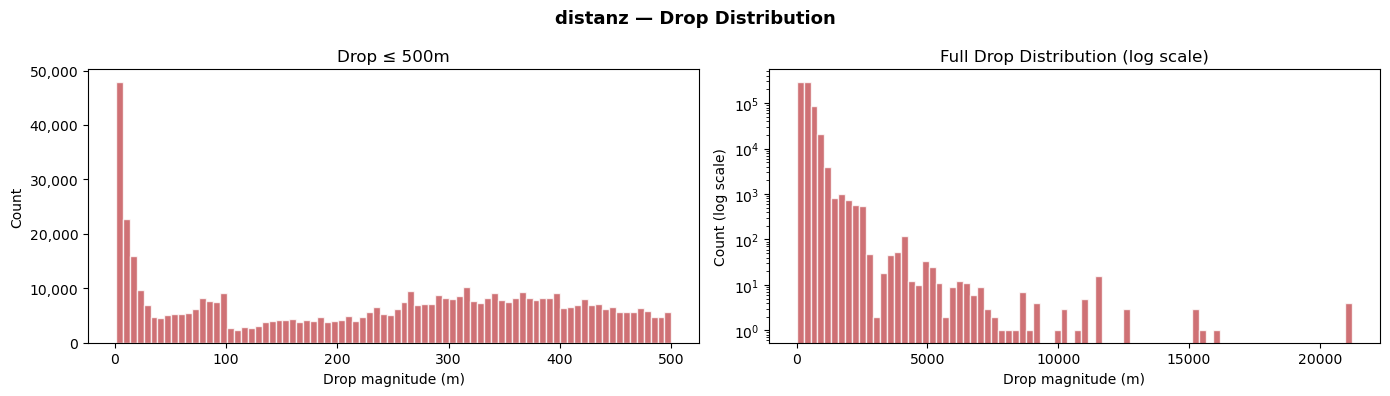

In [3]:
# Cell 3 — distanz drop 分布
# drop定义：同一fahrt_id内，distanz从较大值降回较小值（到站重置）
distanz_diff = (
    df.sort(["fahrt_id", "tst_iso"])
    .with_columns(
        pl.col("distanz").diff().over("fahrt_id").alias("distanz_diff")
    )
    .filter(pl.col("distanz_diff").is_not_null())
)

drops = distanz_diff.filter(pl.col("distanz_diff") < 0)
drop_vals = drops["distanz_diff"].to_numpy()  # 负值，表示下降幅度

print(f"Drop事件总数 : {len(drops):,}")
print(f"Drop占总行数 : {len(drops)/len(df):.3%}")
print("\nDrop幅度统计（绝对值）：")
print(drops["distanz_diff"].abs().describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("distanz — Drop Distribution", fontsize=13, fontweight="bold")

drop_abs = np.abs(drop_vals)

# 左：0-2000m的drop
ax = axes[0]
ax.hist(drop_abs[drop_abs <= 500], bins=80, color="#C44E52", alpha=0.8, edgecolor="white")
ax.set_xlabel("Drop magnitude (m)")
ax.set_ylabel("Count")
ax.set_title("Drop ≤ 500m")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：完整drop分布 log scale
ax2 = axes[1]
ax2.hist(drop_abs, bins=80, color="#C44E52", alpha=0.8, edgecolor="white")
ax2.set_yscale("log")
ax2.set_xlabel("Drop magnitude (m)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Full Drop Distribution (log scale)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_distanz_drop.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Cell 3b — 细看小drop的分布，找噪声阈值
drop_events = (
    df.sort(["fahrt_id", "tst_iso"])
    .with_columns(
        pl.col("distanz").diff().over("fahrt_id").alias("distanz_diff")
    )
    .filter(pl.col("distanz_diff") < 0)
    .with_columns(
        (pl.col("distanz") - pl.col("distanz_diff")).alias("distanz_before_drop")
    )
)

# 分段统计
thresholds = [10, 25, 50, 75, 100, 150, 200]
total_drops = len(drop_events)
print(f"总drop数: {total_drops:,}")
print()
print("distanz_before_drop 分布：")
for t in thresholds:
    n = drop_events.filter(pl.col("distanz_before_drop") < t).height
    print(f"  < {t:4d}m : {n:7,}  ({n/total_drops:.3%})")

print()
# 看0-100m的详细分布
print("0-100m 分位数：")
small_drops = drop_events.filter(pl.col("distanz_before_drop") < 100)
print(small_drops["distanz_before_drop"].describe())

总drop数: 699,035

distanz_before_drop 分布：
  <   10m :  32,766  (4.687%)
  <   25m :  54,816  (7.842%)
  <   50m :  64,967  (9.294%)
  <   75m :  83,331  (11.921%)
  <  100m : 115,738  (16.557%)
  <  150m : 142,158  (20.336%)
  <  200m : 172,614  (24.693%)

0-100m 分位数：
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 115738.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 41.809734 │
│ std        ┆ 35.257019 │
│ min        ┆ 1.0       │
│ 25%        ┆ 8.0       │
│ 50%        ┆ 32.0      │
│ 75%        ┆ 78.0      │
│ max        ┆ 99.0      │
└────────────┴───────────┘


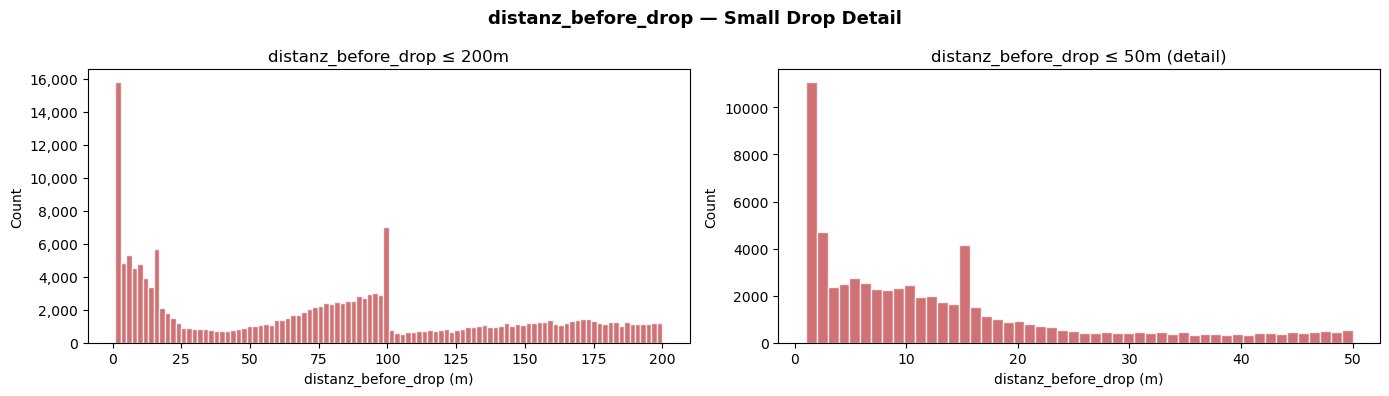

In [5]:
# Cell 3c — 可视化小drop端
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("distanz_before_drop — Small Drop Detail", fontsize=13, fontweight="bold")

vals = drop_events["distanz_before_drop"].to_numpy()

# 左：0-200m细节
ax = axes[0]
ax.hist(vals[vals <= 200], bins=100, color="#C44E52", alpha=0.8, edgecolor="white")
ax.set_xlabel("distanz_before_drop (m)")
ax.set_ylabel("Count")
ax.set_title("distanz_before_drop ≤ 200m")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：0-50m超细节，找valley
ax2 = axes[1]
ax2.hist(vals[vals <= 50], bins=50, color="#C44E52", alpha=0.8, edgecolor="white")
ax2.set_xlabel("distanz_before_drop (m)")
ax2.set_ylabel("Count")
ax2.set_title("distanz_before_drop ≤ 50m (detail)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_drop_small_detail.png", dpi=150, bbox_inches="tight")
plt.show()

Increase事件总数 : 2,630,509

Increase幅度统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2.630509e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 89.089732  │
│ std        ┆ 76.899304  │
│ min        ┆ 1.0        │
│ 25%        ┆ 32.0       │
│ 50%        ┆ 84.0       │
│ 75%        ┆ 131.0      │
│ max        ┆ 21034.0    │
└────────────┴────────────┘
P90.0 : 170.0 m
P95.0 : 195.0 m
P99.0 : 255.0 m
P99.9 : 635.0 m


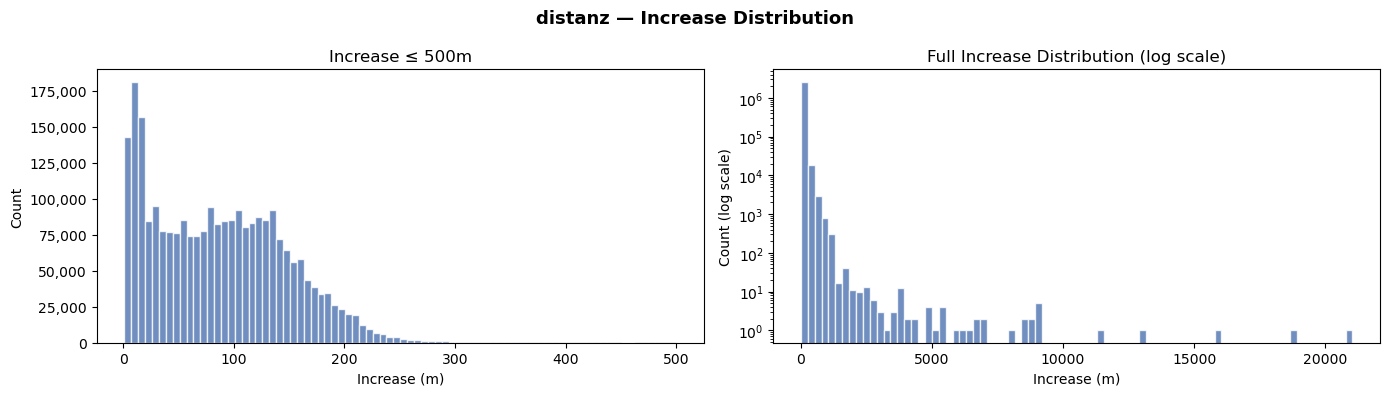

In [6]:
# Cell 4 — distanz increase 分布
increases = distanz_diff.filter(pl.col("distanz_diff") > 0)
inc_vals = increases["distanz_diff"].to_numpy()

print(f"Increase事件总数 : {len(increases):,}")
print("\nIncrease幅度统计：")
print(increases["distanz_diff"].describe())

# 分位数
for p in [0.9, 0.95, 0.99, 0.999]:
    val = increases["distanz_diff"].quantile(p)
    print(f"P{p*100:.1f} : {val:.1f} m")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("distanz — Increase Distribution", fontsize=13, fontweight="bold")

# 左：0-500m 正常范围
ax = axes[0]
ax.hist(inc_vals[inc_vals <= 500], bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.set_xlabel("Increase (m)")
ax.set_ylabel("Count")
ax.set_title("Increase ≤ 500m")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：完整分布 log scale
ax2 = axes[1]
ax2.hist(inc_vals, bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.set_yscale("log")
ax2.set_xlabel("Increase (m)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Full Increase Distribution (log scale)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_distanz_increase.png", dpi=150, bbox_inches="tight")
plt.show()

pos_lat 统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.728505e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 51.053194  │
│ std        ┆ 0.052845   │
│ min        ┆ 0.0        │
│ 25%        ┆ 51.027272  │
│ 50%        ┆ 51.048973  │
│ 75%        ┆ 51.078488  │
│ max        ┆ 51.35335   │
└────────────┴────────────┘

pos_lon 统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.728505e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 13.759097  │
│ std        ┆ 0.060741   │
│ min        ┆ 0.0        │
│ 25%        ┆ 13.715567  │
│ 50%        ┆ 13.760317  │
│ 75%        ┆ 13.796683  │
│ max        ┆ 14.189267  │
└────────────┴────────────┘

边界外记录数 : 31,248  (0.5455%)


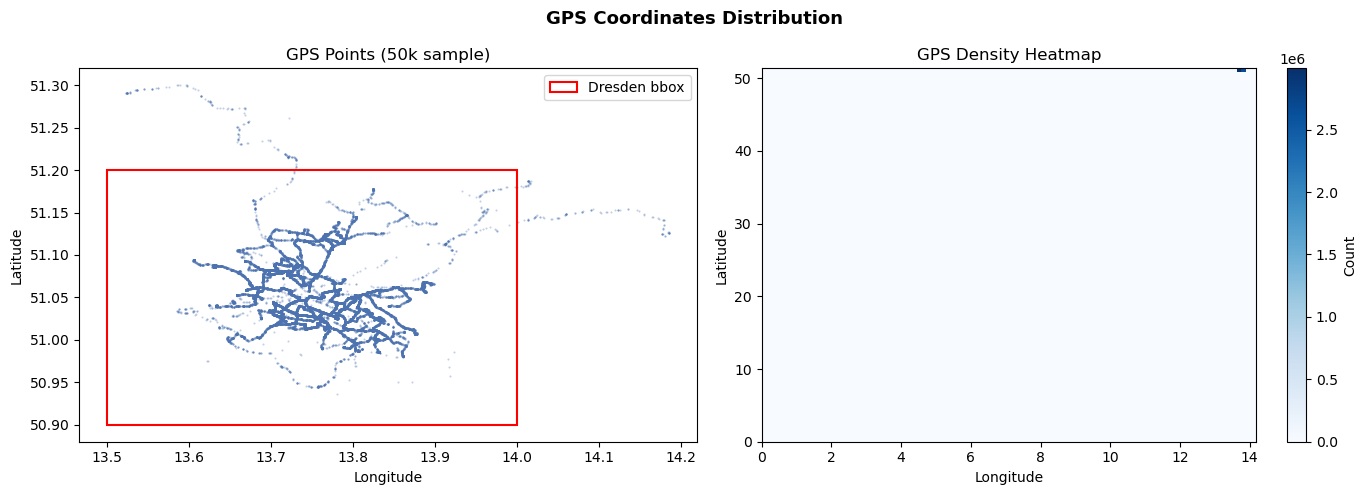

In [8]:
# Cell 5 — 经纬度分布
print("pos_lat 统计：")
print(df["pos_lat"].describe())
print("\npos_lon 统计：")
print(df["pos_lon"].describe())

# Dresden边界框（理论值）
LAT_MIN, LAT_MAX = 50.9, 51.2
LON_MIN, LON_MAX = 13.5, 14.0

out_of_bounds = df.filter(
    (pl.col("pos_lat") < LAT_MIN) | (pl.col("pos_lat") > LAT_MAX) |
    (pl.col("pos_lon") < LON_MIN) | (pl.col("pos_lon") > LON_MAX)
)
print(f"\n边界外记录数 : {len(out_of_bounds):,}  ({len(out_of_bounds)/len(df):.4%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GPS Coordinates Distribution", fontsize=13, fontweight="bold")

# 左：散点图（subsample避免过慢）
sample = df.sample(n=min(50000, len(df)), seed=42)
ax = axes[0]
ax.scatter(sample["pos_lon"].to_numpy(), sample["pos_lat"].to_numpy(),
           s=0.3, alpha=0.3, color="#4C72B0")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("GPS Points (50k sample)")
# 画Dresden边界框
from matplotlib.patches import Rectangle
rect = Rectangle((LON_MIN, LAT_MIN), LON_MAX-LON_MIN, LAT_MAX-LAT_MIN,
                 linewidth=1.5, edgecolor="red", facecolor="none",
                 label="Dresden bbox")
ax.add_patch(rect)
ax.legend()

# 右：2D密度直方图
ax2 = axes[1]
h = ax2.hist2d(
    df["pos_lon"].to_numpy(), df["pos_lat"].to_numpy(),
    bins=100, cmap="Blues"
)
plt.colorbar(h[3], ax=ax2, label="Count")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("GPS Density Heatmap")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_gps.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Cell 5b — 诊断异常坐标
# 看lat=0或lon=0的记录
zero_coords = df.filter(
    (pl.col("pos_lat") == 0) | (pl.col("pos_lon") == 0)
)
print(f"lat或lon为0的记录数: {len(zero_coords):,}")
print(zero_coords.select(["tst_iso", "fzg_id", "linie", "pos_lat", "pos_lon"]).head(10))

# 从实际数据范围重新定边界框
lat_vals = df.filter(pl.col("pos_lat") > 1)["pos_lat"]  # 排除0值
lon_vals = df.filter(pl.col("pos_lon") > 1)["pos_lon"]

print(f"\n排除0值后：")
print(f"lat: {lat_vals.min():.4f} ~ {lat_vals.max():.4f}")
print(f"lon: {lon_vals.min():.4f} ~ {lon_vals.max():.4f}")

lat或lon为0的记录数: 3
shape: (3, 5)
┌────────────────────────────────┬────────┬───────┬─────────┬─────────┐
│ tst_iso                        ┆ fzg_id ┆ linie ┆ pos_lat ┆ pos_lon │
│ ---                            ┆ ---    ┆ ---   ┆ ---     ┆ ---     │
│ datetime[μs, UTC]              ┆ i64    ┆ i64   ┆ f64     ┆ f64     │
╞════════════════════════════════╪════════╪═══════╪═════════╪═════════╡
│ 2025-07-29 16:42:19.390201 UTC ┆ 301964 ┆ 520   ┆ 0.0     ┆ 0.0     │
│ 2025-08-01 05:30:04.494623 UTC ┆ 27308  ┆ 81    ┆ 0.0     ┆ 0.0     │
│ 2025-08-01 05:30:23.106517 UTC ┆ 27308  ┆ 81    ┆ 0.0     ┆ 0.0     │
└────────────────────────────────┴────────┴───────┴─────────┴─────────┘

排除0值后：
lat: 50.9344 ~ 51.3533
lon: 13.4383 ~ 14.1893


自适应边界框: lat [50.9472, 51.2810], lon [13.5894, 14.0821]
边界外记录数（排除0值后）: 18,243


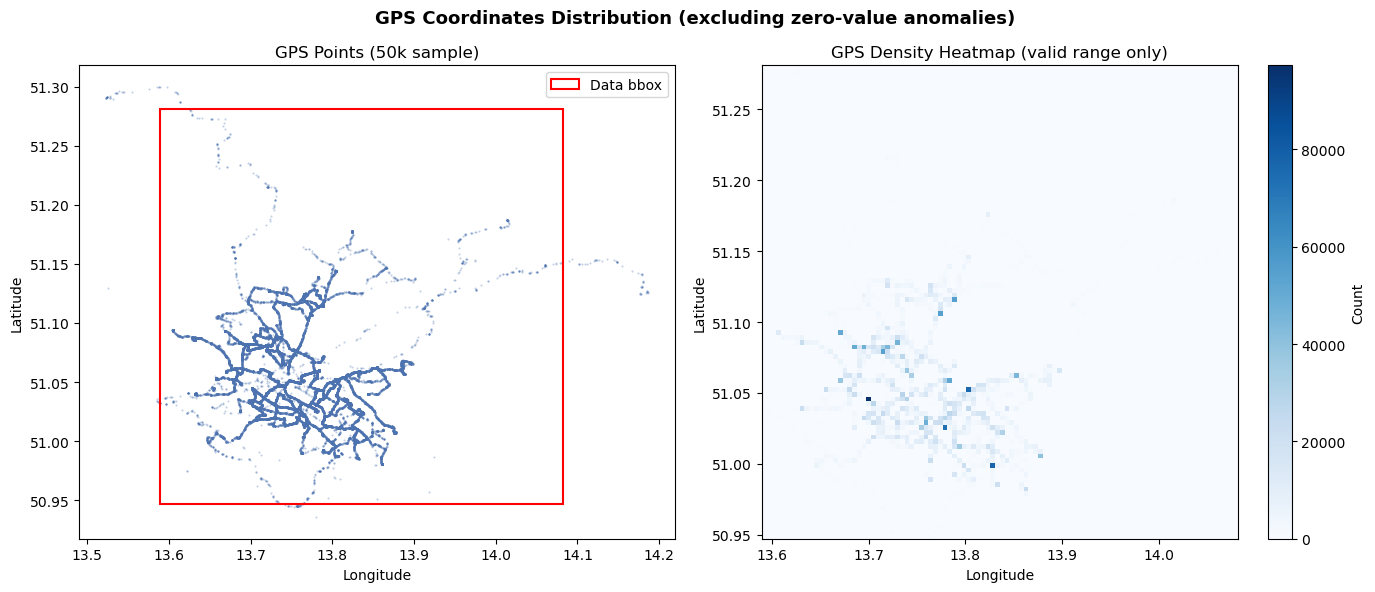

In [10]:
# Cell 5c — 修正后的可视化（排除0值异常点）
df_valid_gps = df.filter(
    (pl.col("pos_lat") > 1) & (pl.col("pos_lon") > 1)
)

# 从数据实际范围定边界框（加一点padding）
LAT_MIN = float(df_valid_gps["pos_lat"].quantile(0.001))
LAT_MAX = float(df_valid_gps["pos_lat"].quantile(0.999))
LON_MIN = float(df_valid_gps["pos_lon"].quantile(0.001))
LON_MAX = float(df_valid_gps["pos_lon"].quantile(0.999))

print(f"自适应边界框: lat [{LAT_MIN:.4f}, {LAT_MAX:.4f}], lon [{LON_MIN:.4f}, {LON_MAX:.4f}]")

# 边界外记录（排除0值后重新统计）
out_of_bounds = df_valid_gps.filter(
    (pl.col("pos_lat") < LAT_MIN) | (pl.col("pos_lat") > LAT_MAX) |
    (pl.col("pos_lon") < LON_MIN) | (pl.col("pos_lon") > LON_MAX)
)
print(f"边界外记录数（排除0值后）: {len(out_of_bounds):,}")

sample = df_valid_gps.sample(n=min(50000, len(df_valid_gps)), seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("GPS Coordinates Distribution (excluding zero-value anomalies)",
             fontsize=13, fontweight="bold")

# 左：散点图
ax = axes[0]
ax.scatter(
    sample["pos_lon"].to_numpy(),
    sample["pos_lat"].to_numpy(),
    s=0.3, alpha=0.3, color="#4C72B0"
)
from matplotlib.patches import Rectangle
rect = Rectangle(
    (LON_MIN, LAT_MIN), LON_MAX - LON_MIN, LAT_MAX - LAT_MIN,
    linewidth=1.5, edgecolor="red", facecolor="none", label="Data bbox"
)
ax.add_patch(rect)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("GPS Points (50k sample)")
ax.legend()

# 右：2D density heatmap（只用有效范围内的数据）
df_bbox = df_valid_gps.filter(
    (pl.col("pos_lat") >= LAT_MIN) & (pl.col("pos_lat") <= LAT_MAX) &
    (pl.col("pos_lon") >= LON_MIN) & (pl.col("pos_lon") <= LON_MAX)
)
ax2 = axes[1]
h = ax2.hist2d(
    df_bbox["pos_lon"].to_numpy(),
    df_bbox["pos_lat"].to_numpy(),
    bins=100, cmap="Blues"
)
plt.colorbar(h[3], ax=ax2, label="Count")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("GPS Density Heatmap (valid range only)")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_gps.png", dpi=150, bbox_inches="tight")
plt.show()

lage 非空行数 : 5,728,505  (100.00%)
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.728505e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 43.551287  │
│ std        ┆ 200.173494 │
│ min        ┆ -5385.0    │
│ 25%        ┆ 0.0        │
│ 50%        ┆ 10.0       │
│ 75%        ┆ 80.0       │
│ max        ┆ 10004.0    │
└────────────┴────────────┘
P1.0 : -510s
P5.0 : -70s
P95.0 : 260s
P99.0 : 600s
P99.9 : 1880s


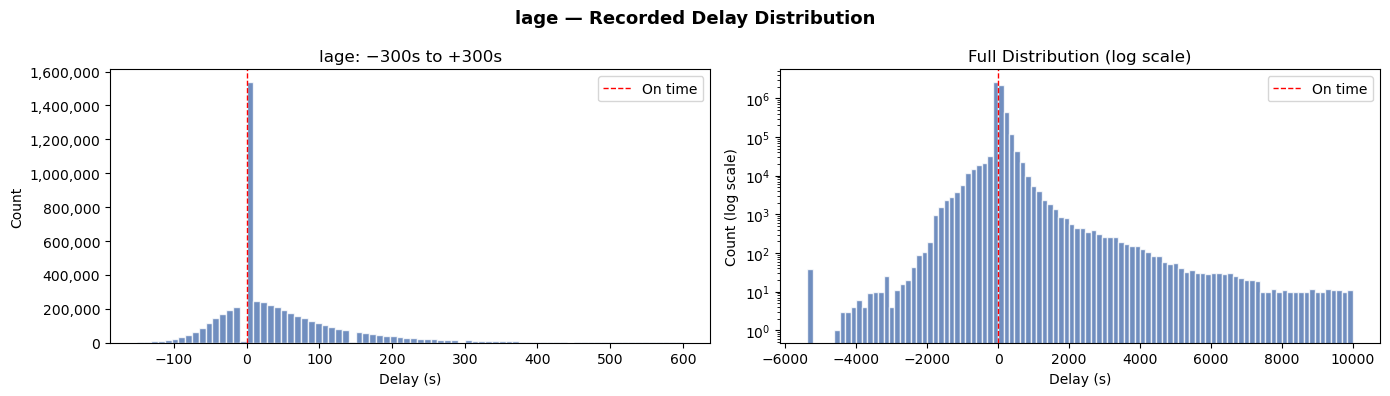

In [11]:
# Cell 6 — lage（车载自报延误）分布
lage = df.filter(pl.col("lage").is_not_null())
print(f"lage 非空行数 : {len(lage):,}  ({len(lage)/len(df):.2%})")
print(lage["lage"].describe())

for p in [0.01, 0.05, 0.95, 0.99, 0.999]:
    val = lage["lage"].quantile(p)
    print(f"P{p*100:.1f} : {val:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("lage — Recorded Delay Distribution", fontsize=13, fontweight="bold")

lage_vals = lage["lage"].to_numpy()

# 左：-150s 到 300s 的正常范围
ax = axes[0]
clipped = lage_vals[(lage_vals >= -150) & (lage_vals <= 600)]
ax.hist(clipped, bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="On time")
ax.set_xlabel("Delay (s)")
ax.set_ylabel("Count")
ax.set_title("lage: −300s to +300s")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：完整分布 log scale
ax2 = axes[1]
ax2.hist(lage_vals, bins=100, color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.set_yscale("log")
ax2.axvline(0, color="red", linestyle="--", linewidth=1, label="On time")
ax2.set_xlabel("Delay (s)")
ax2.set_ylabel("Count (log scale)")
ax2.set_title("Full Distribution (log scale)")
ax2.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_lage.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Cell 6c — status_text 完整分布
print("status_text 完整分布：")
print(
    df.group_by("status_text")
    .count()
    .sort("count", descending=True)
    .with_columns(
        (pl.col("count") / len(df)).alias("ratio")
    )
)

status_text 完整分布：
shape: (7, 3)
┌─────────────┬─────────┬──────────┐
│ status_text ┆ count   ┆ ratio    │
│ ---         ┆ ---     ┆ ---      │
│ str         ┆ u32     ┆ f64      │
╞═════════════╪═════════╪══════════╡
│ planm       ┆ 5248424 ┆ 0.916194 │
│ vvo         ┆ 240274  ┆ 0.041944 │
│ posUnklar   ┆ 153283  ┆ 0.026758 │
│ verlRoute   ┆ 37937   ┆ 0.006622 │
│ ohneFahrt   ┆ 28500   ┆ 0.004975 │
│ dispo       ┆ 20062   ┆ 0.003502 │
│ keinFunk    ┆ 25      ┆ 0.000004 │
└─────────────┴─────────┴──────────┘


/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11420/3690778454.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


In [13]:
# Cell 6b — lage=0 的诊断
zero_lage = df.filter(pl.col("lage") == 0)
nonzero_lage = df.filter(pl.col("lage") != 0)

print(f"lage=0  : {len(zero_lage):,}  ({len(zero_lage)/len(df):.2%})")
print(f"lage≠0  : {len(nonzero_lage):,}  ({len(nonzero_lage)/len(df):.2%})")

# 看lage=0时status_text的分布
# 如果大量lage=0对应status_text="planm"（正点），说明是真实准点
# 如果对应各种status，说明是默认值
print("\nlage=0 时的 status_text 分布：")
print(
    zero_lage.group_by("status_text")
    .count()
    .sort("count", descending=True)
)

# 极端值诊断
extreme_lage = df.filter(pl.col("lage").abs() > 1800)  # >30min
print(f"\n|lage| > 1800s (30min) : {len(extreme_lage):,}  ({len(extreme_lage)/len(df):.4%})")
print(extreme_lage.select(["tst_iso", "fzg_id", "linie", "lage", "status_text"]).head(10))

lage=0  : 1,526,284  (26.64%)
lage≠0  : 4,202,221  (73.36%)

lage=0 时的 status_text 分布：
shape: (6, 2)
┌─────────────┬─────────┐
│ status_text ┆ count   │
│ ---         ┆ ---     │
│ str         ┆ u32     │
╞═════════════╪═════════╡
│ planm       ┆ 1286214 │
│ posUnklar   ┆ 153279  │
│ verlRoute   ┆ 37888   │
│ ohneFahrt   ┆ 27914   │
│ vvo         ┆ 20964   │
│ keinFunk    ┆ 25      │
└─────────────┴─────────┘

|lage| > 1800s (30min) : 6,936  (0.1211%)
shape: (10, 5)
┌────────────────────────────────┬────────┬───────┬───────┬─────────────┐
│ tst_iso                        ┆ fzg_id ┆ linie ┆ lage  ┆ status_text │
│ ---                            ┆ ---    ┆ ---   ┆ ---   ┆ ---         │
│ datetime[μs, UTC]              ┆ i64    ┆ i64   ┆ i64   ┆ str         │
╞════════════════════════════════╪════════╪═══════╪═══════╪═════════════╡
│ 2025-07-27 23:25:30.381180 UTC ┆ 1381   ┆ 63    ┆ -2310 ┆ planm       │
│ 2025-07-27 23:25:35.394657 UTC ┆ 1381   ┆ 63    ┆ -2300 ┆ planm       │
│ 2025-07-2

/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11420/1194386369.py:14: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


besetztgrad 统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 5.728505e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 6.863359   │
│ std        ┆ 11.05879   │
│ min        ┆ -1.0       │
│ 25%        ┆ -1.0       │
│ 50%        ┆ 1.0        │
│ 75%        ┆ 12.0       │
│ max        ┆ 119.0      │
└────────────┴────────────┘

各等级计数：


/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11420/1196641927.py:7: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


shape: (109, 2)
┌─────────────┬─────────┐
│ besetztgrad ┆ count   │
│ ---         ┆ ---     │
│ i64         ┆ u32     │
╞═════════════╪═════════╡
│ -1          ┆ 1890804 │
│ 0           ┆ 892547  │
│ 1           ┆ 185878  │
│ 2           ┆ 180454  │
│ 3           ┆ 156852  │
│ …           ┆ …       │
│ 108         ┆ 44      │
│ 109         ┆ 15      │
│ 116         ┆ 9       │
│ 118         ┆ 11      │
│ 119         ┆ 32      │
└─────────────┴─────────┘


/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_11420/1196641927.py:33: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count()


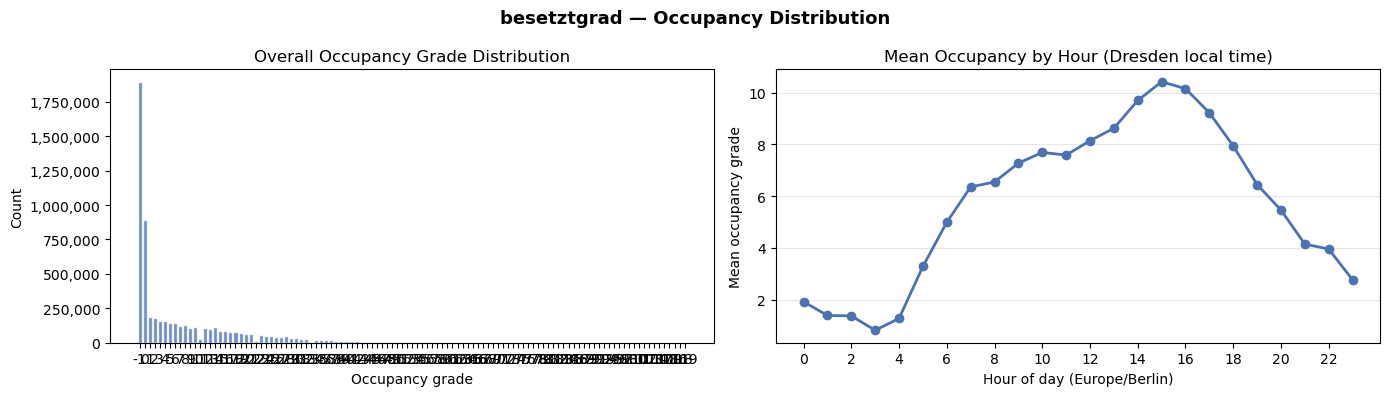

In [14]:
# Cell 7 — besetztgrad 分布（整体 + 按时段）
print("besetztgrad 统计：")
print(df["besetztgrad"].describe())
print("\n各等级计数：")
print(
    df.group_by("besetztgrad")
    .count()
    .sort("besetztgrad")
)

# 添加小时字段（Dresden 本地时间）
df_hour = df.with_columns(
    pl.col("tst_iso")
      .dt.convert_time_zone("Europe/Berlin")
      .dt.hour()
      .alias("hour_local")
)

# 按小时的besetztgrad均值
hourly_occ = (
    df_hour.group_by("hour_local")
    .agg(pl.col("besetztgrad").mean().alias("mean_besetztgrad"))
    .sort("hour_local")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("besetztgrad — Occupancy Distribution", fontsize=13, fontweight="bold")

# 左：整体分布（bar chart，每个等级一根）
ax = axes[0]
grade_counts = (
    df.group_by("besetztgrad")
    .count()
    .sort("besetztgrad")
)
ax.bar(
    [str(x) for x in grade_counts["besetztgrad"].to_list()],
    grade_counts["count"].to_list(),
    color="#4C72B0", alpha=0.8, edgecolor="white"
)
ax.set_xlabel("Occupancy grade")
ax.set_ylabel("Count")
ax.set_title("Overall Occupancy Grade Distribution")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：按小时的平均载客率（折线，Dresden 本地时间）
ax2 = axes[1]
hours = hourly_occ["hour_local"].to_list()
means = hourly_occ["mean_besetztgrad"].to_list()
ax2.plot(hours, means, marker="o", color="#4C72B0", linewidth=2)
ax2.set_xlabel("Hour of day (Europe/Berlin)")
ax2.set_ylabel("Mean occupancy grade")
ax2.set_title("Mean Occupancy by Hour (Dresden local time)")
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_besetztgrad.png", dpi=150, bbox_inches="tight")
plt.show()

无数据(-1)占比: 33.01%
有效数据占比  : 66.99%

有效数据统计：
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 3.837701e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 10.737572  │
│ std        ┆ 11.708017  │
│ min        ┆ 0.0        │
│ 25%        ┆ 1.0        │
│ 50%        ┆ 7.0        │
│ 75%        ┆ 17.0       │
│ max        ┆ 119.0      │
└────────────┴────────────┘


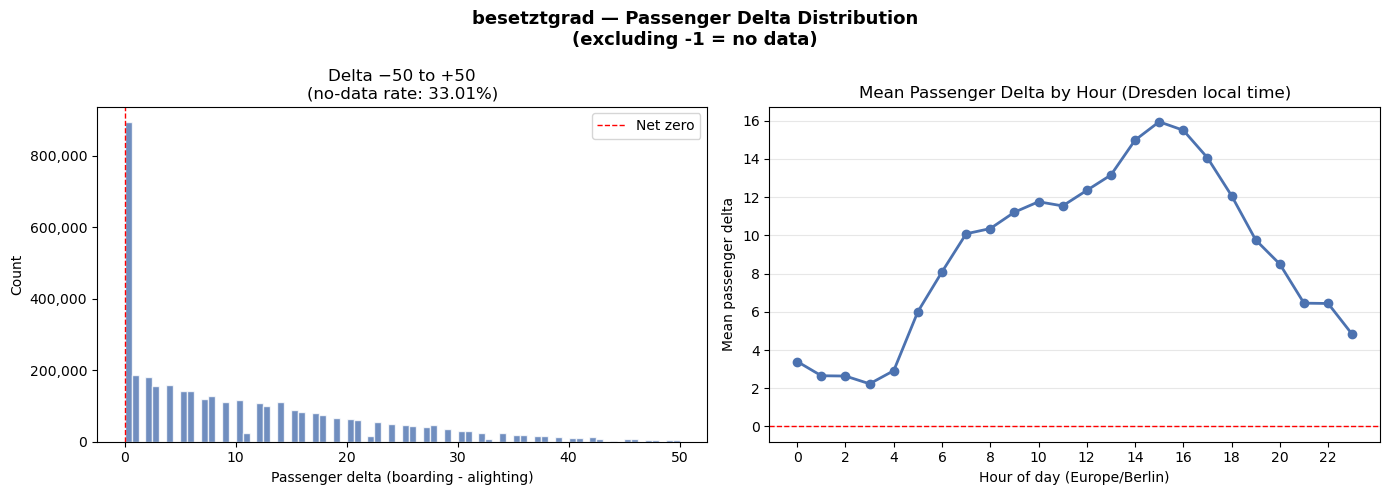

In [15]:
# Cell 7c — 修正后的 besetztgrad 可视化
df_bez = df.filter(pl.col("besetztgrad") != -1)  # 排除无数据
no_data_rate = df.filter(pl.col("besetztgrad") == -1).height / len(df)

print(f"无数据(-1)占比: {no_data_rate:.2%}")
print(f"有效数据占比  : {1-no_data_rate:.2%}")
print(f"\n有效数据统计：")
print(df_bez["besetztgrad"].describe())

df_hour = df_bez.with_columns(
    pl.col("tst_iso")
      .dt.convert_time_zone("Europe/Berlin")
      .dt.hour()
      .alias("hour_local")
)
hourly = (
    df_hour.group_by("hour_local")
    .agg(pl.col("besetztgrad").mean().alias("mean_delta"))
    .sort("hour_local")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("besetztgrad — Passenger Delta Distribution\n(excluding -1 = no data)",
             fontsize=13, fontweight="bold")

bez_vals = df_bez["besetztgrad"].to_numpy()

# 左：delta分布（-50到50的核心范围）
ax = axes[0]
clipped = bez_vals[(bez_vals >= -50) & (bez_vals <= 50)]
ax.hist(clipped, bins=80, color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="Net zero")
ax.set_xlabel("Passenger delta (boarding - alighting)")
ax.set_ylabel("Count")
ax.set_title(f"Delta −50 to +50\n(no-data rate: {no_data_rate:.2%})")
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

# 右：按小时的平均delta（Dresden 本地时间）
ax2 = axes[1]
ax2.plot(hourly["hour_local"].to_list(),
         hourly["mean_delta"].to_list(),
         marker="o", color="#4C72B0", linewidth=2)
ax2.axhline(0, color="red", linestyle="--", linewidth=1)
ax2.set_xlabel("Hour of day (Europe/Berlin)")
ax2.set_ylabel("Mean passenger delta")
ax2.set_title("Mean Passenger Delta by Hour (Dresden local time)")
ax2.set_xticks(range(0, 24, 2))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/A3_besetztgrad.png", dpi=150, bbox_inches="tight")
plt.show()